In [ ]:
import zipfile
import os
import tensorflow as tf
import json
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Skripsi_dataset/1_dataset_nw.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("Sedang mengekstrak dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Ekstrasi selesai!")
else:
    print("Dataset sudah ada.")

Sedang mengekstrak dataset...
Ekstrasi selesai!


In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 50
NUM_CLASSES = 26
TRAIN_DIR = '/content/dataset/train'
VAL_DIR = '/content/dataset/val'
TEST_DIR = '/content/dataset/test'
MODEL_SAVE_PATH = '/content/drive/MyDrive/Skripsi_dataset/fix_bisindo.keras'

In [ ]:
# --- AUGMENTASI DAN PREPROCESSING ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input)

# --- LOAD DATA ---
print("Mengambil Data Training...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=123)

print("\nMengambil Data Validation...")
val_generator = train_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=123)

print("\nMengambil Data Test...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=123)

print(f"\nTotal training samples: {train_generator.samples}")
print(f"Total validation samples: {val_generator.samples}")
print(f"Total test samples: {test_generator.samples}")

Mengambil Data Training...
Found 780 images belonging to 26 classes.

Mengambil Data Validation...
Found 260 images belonging to 26 classes.

Mengambil Data Test...
Found 260 images belonging to 26 classes.

Total training samples: 780
Total validation samples: 260
Total test samples: 260


In [ ]:
# --- BUILD MODEL RESNET 50 ---
def build_transfer_learning_model(num_classes, trainable_layers=0):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D(name='global_avg_pooling')(x)
    x = Dropout(0.5, name='dropout_1')(x)
    x = Dense(512, activation='relu', name='fc1')(x)
    x = Dropout(0.3, name='dropout_2')(x)
    outputs = Dense(num_classes, activation='softmax', name='predictions')(x)
    model = Model(inputs=base_model.input, outputs=outputs, name='ResNet50_BISINDO')

    # Fine-tuning
    if trainable_layers > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
        print(f"Fine-tuning: {trainable_layers} layer terakhir di-unfreeze")
    elif trainable_layers == -1:
        base_model.trainable = True
        print("Fine-tuning: Semua layer di-unfreeze")
    else:
        print("Feature extraction only: Semua base model layers di-freeze")
    return model

In [ ]:
# --- COMPILE MODEL ---
model = build_transfer_learning_model(NUM_CLASSES, trainable_layers=0)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# --- CALLBACKS ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1)]

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extraction only: Semua base model layers di-freeze


Model: "ResNet50_BISINDO"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,650,138 (94.03 MB)

 Trainable params: 1,062,426 (4.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total parameters: 24,650,138
Trainable parameters: 1,062,426


In [ ]:
# --- TRAINING MODEL ---
# --- PHASE 1 ---
print("\n" + "="*60)
print("PHASE 1: FEATURE EXTRACTION")
print("="*60 + "\n")

history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1)

# --- PHASE 2: FINE-TUNING ---
print("\n" + "="*60)
print("PHASE 2: FINE-TUNING (Unfreeze beberapa layer)")
print("="*60 + "\n")

model = tf.keras.models.load_model(MODEL_SAVE_PATH)

print(f"Total layers dalam model: {len(model.layers)}")
print(f"Nama beberapa layer awal: {[layer.name for layer in model.layers[:5]]}")
print(f"Nama beberapa layer akhir: {[layer.name for layer in model.layers[-5:]]}")

resnet_layer_count = 0
for i, layer in enumerate(model.layers):
    if any(name in layer.name.lower() for name in ['global_avg_pooling', 'dropout', 'fc1', 'predictions', 'flatten']):
        resnet_layer_count = i
        break

if resnet_layer_count == 0:
    resnet_layer_count = len(model.layers) - 5

print(f"\nEstimasi jumlah layer ResNet50: {resnet_layer_count}")
print(f"Layer ke-{resnet_layer_count}: {model.layers[resnet_layer_count].name}")

# Fine-tuning strategy
LAYERS_TO_UNFREEZE = 30
unfreeze_from = max(0, resnet_layer_count - LAYERS_TO_UNFREEZE)

print(f"\nStrategi fine-tuning:")
print(f"- Freeze layers 0 sampai {unfreeze_from-1}")
print(f"- Unfreeze layers {unfreeze_from} sampai {resnet_layer_count-1} (ResNet50)")
print(f"- Unfreeze layers {resnet_layer_count} sampai {len(model.layers)-1} (Custom layers)")

for i, layer in enumerate(model.layers):
    if i < unfreeze_from:
        layer.trainable = False
    else:
        layer.trainable = True

trainable_count = sum([layer.trainable for layer in model.layers])
print(f"\nTotal trainable layers: {trainable_count}/{len(model.layers)}")

# Re-compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_SAVE_PATH.replace('.keras', '_finetuned.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1)]

print("\nMulai fine-tuning...")
print("Ini akan memakan waktu lebih lama dari Phase 1\n")

history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=20,
    callbacks=finetune_callbacks,
    verbose=1)

for key in history_phase1.history.keys():
    history_phase1.history[key].extend(history_phase2.history[key])

print("\nFine-tuning selesai!")
print(f"Model fine-tuned disimpan di: {MODEL_SAVE_PATH.replace('.keras', '_finetuned.keras')}")


PHASE 1: FEATURE EXTRACTION



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.0597 - loss: 4.4291
Epoch 1: val_accuracy improved from -inf to 0.26172, saving model to /content/drive/MyDrive/Skripsi_dataset/fix_bisindo.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.0601 - loss: 4.4117 - val_accuracy: 0.2617 - val_loss: 2.7855 - learning_rate: 0.0010
Epoch 2/50
 1/24 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.0625 - loss: 3.1398

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.26172
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.0625 - loss: 3.1398 - val_accuracy: 0.2305 - val_loss: 2.7512 - learning_rate: 0.0010
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.1957 - loss: 2.8069
Epoch 3: val_accuracy improved from 0.26172 to 0.37891, saving model to /content/drive/MyDrive/Skripsi_dataset/fix_bisindo.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 902ms/step - accuracy: 0.1970 - loss: 2.8047 - val_accuracy: 0.3789 - val_loss: 2.3410 - learning_rate: 0.0010
Epoch 4/50
 1/24 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.2188 - loss: 2.6060
Epoch 4: val_accuracy improved from 0.37891 to 0.38672, saving model to /content/drive/MyDrive/Skripsi_dataset/fix_bisindo.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - accuracy: 0.2188 - loss: 2.6060 - val_accuracy: 0.3867 - val_loss: 2.3347 - learning_rate: 0.0010
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.3400 - loss: 2.3091
Epoch 5:

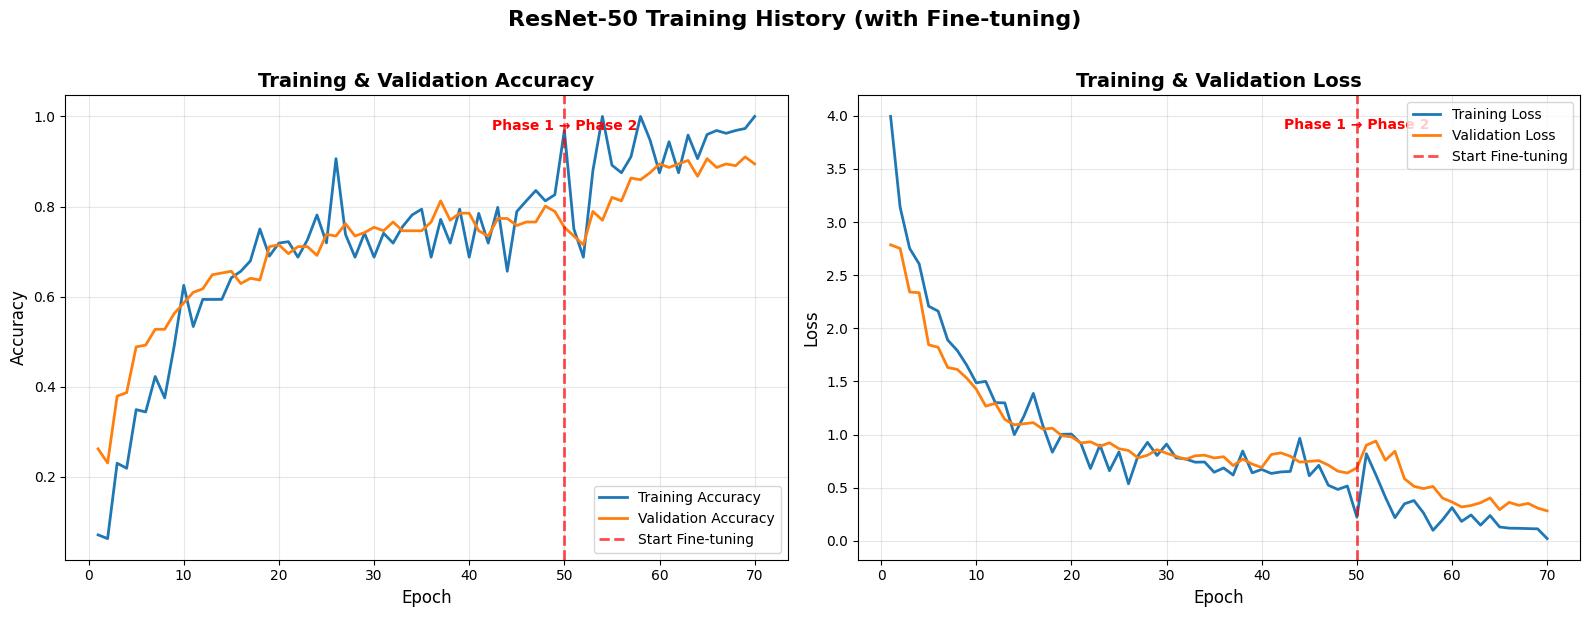


PERBANDINGAN PHASE 1 vs PHASE 2

Phase 1 (Feature Extraction):
  Best Validation Accuracy: 0.8125 (81.25%)

Phase 2 (Fine-tuning):
  Best Validation Accuracy: 0.9102 (91.02%)

Improvement: +9.77%


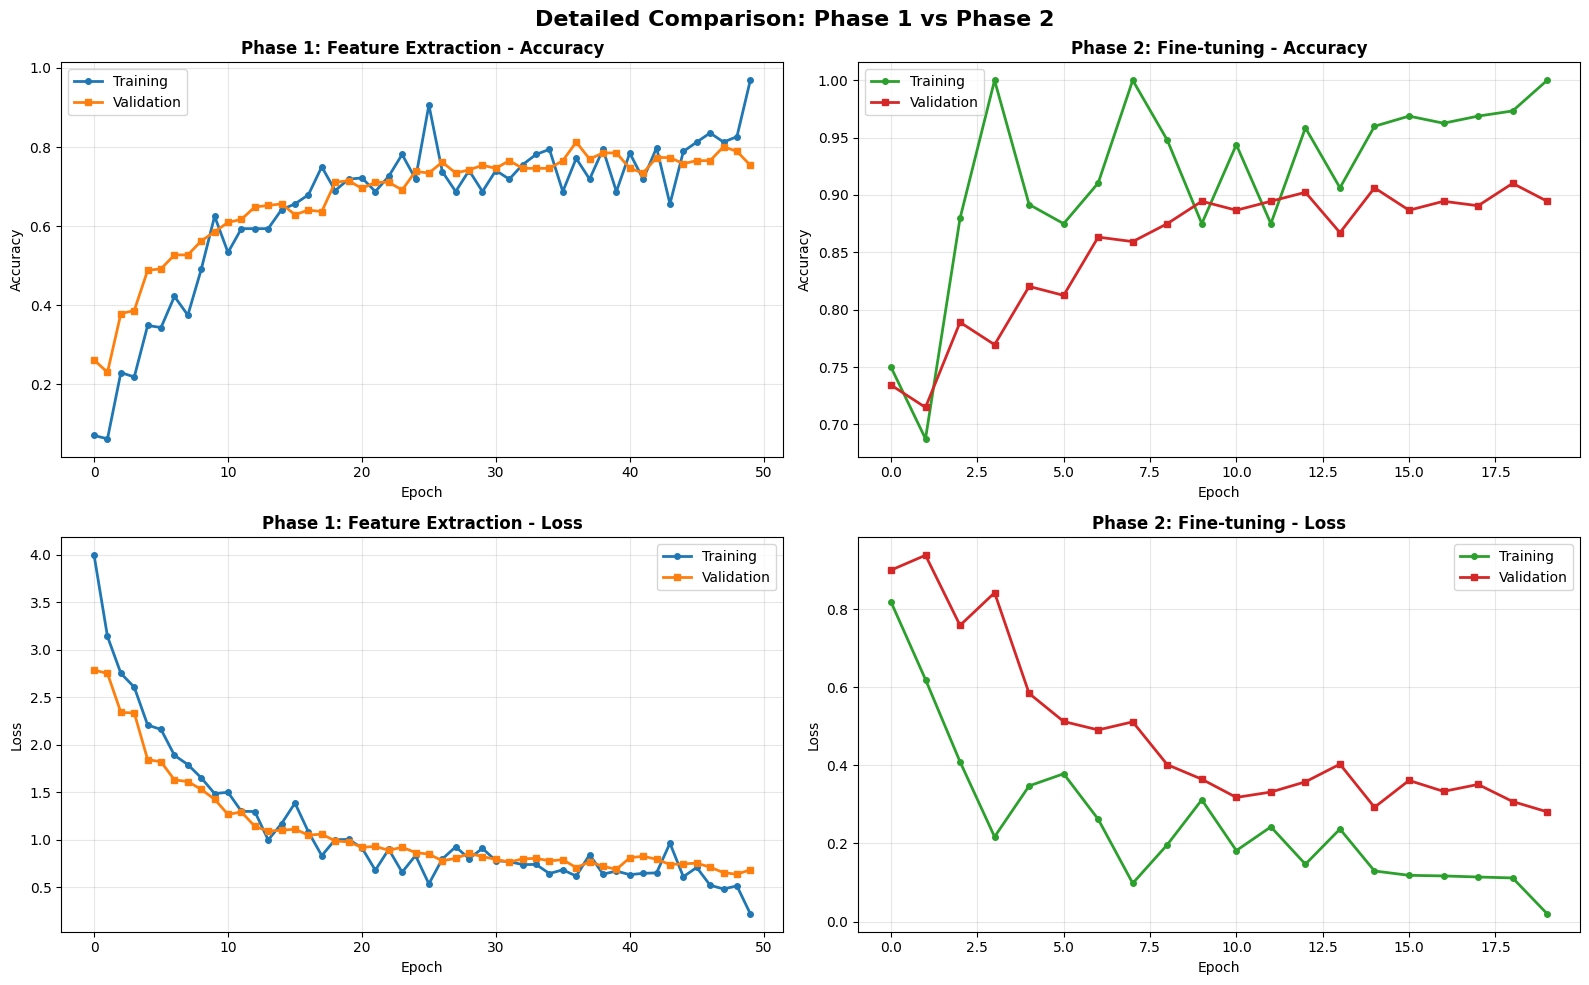

In [ ]:
# --- PLOT TRAINING ---
history = history_phase1
has_finetuning = len(history.history['accuracy']) > EPOCHS
phase1_epochs = EPOCHS if not has_finetuning else EPOCHS

plt.figure(figsize=(16, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
epochs_range = range(1, len(history.history['accuracy']) + 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#1f77b4')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#ff7f0e')

if has_finetuning:
    plt.axvline(x=phase1_epochs, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Start Fine-tuning')
    plt.text(phase1_epochs, plt.ylim()[1]*0.95, 'Phase 1 → Phase 2',
             ha='center', va='top', fontsize=10, color='red', fontweight='bold')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss', linewidth=2, color='#1f77b4')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss', linewidth=2, color='#ff7f0e')

if has_finetuning:
    plt.axvline(x=phase1_epochs, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Start Fine-tuning')
    plt.text(phase1_epochs, plt.ylim()[1]*0.95, 'Phase 1 → Phase 2',
             ha='center', va='top', fontsize=10, color='red', fontweight='bold')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.suptitle('ResNet-50 Training History' + (' (with Fine-tuning)' if has_finetuning else ''),
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- PLOT PERBANDINGAN PHASE 1 vs PHASE 2 ---
if has_finetuning:
    print("\n" + "="*60)
    print("PERBANDINGAN PHASE 1 vs PHASE 2")
    print("="*60 + "\n")

    phase1_acc = history.history['accuracy'][:phase1_epochs]
    phase2_acc = history.history['accuracy'][phase1_epochs:]
    phase1_val_acc = history.history['val_accuracy'][:phase1_epochs]
    phase2_val_acc = history.history['val_accuracy'][phase1_epochs:]

    best_phase1_val_acc = max(phase1_val_acc)
    best_phase2_val_acc = max(phase2_val_acc)
    improvement = (best_phase2_val_acc - best_phase1_val_acc) * 100

    print(f"Phase 1 (Feature Extraction):")
    print(f"  Best Validation Accuracy: {best_phase1_val_acc:.4f} ({best_phase1_val_acc*100:.2f}%)")
    print(f"\nPhase 2 (Fine-tuning):")
    print(f"  Best Validation Accuracy: {best_phase2_val_acc:.4f} ({best_phase2_val_acc*100:.2f}%)")
    print(f"\nImprovement: {improvement:+.2f}%")
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Phase 1 Accuracy
    axes[0, 0].plot(phase1_acc, label='Training', linewidth=2, marker='o', markersize=4)
    axes[0, 0].plot(phase1_val_acc, label='Validation', linewidth=2, marker='s', markersize=4)
    axes[0, 0].set_title('Phase 1: Feature Extraction - Accuracy', fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Phase 2 Accuracy
    axes[0, 1].plot(phase2_acc, label='Training', linewidth=2, marker='o', markersize=4, color='#2ca02c')
    axes[0, 1].plot(phase2_val_acc, label='Validation', linewidth=2, marker='s', markersize=4, color='#d62728')
    axes[0, 1].set_title('Phase 2: Fine-tuning - Accuracy', fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Phase 1 Loss
    phase1_loss = history.history['loss'][:phase1_epochs]
    phase1_val_loss = history.history['val_loss'][:phase1_epochs]
    axes[1, 0].plot(phase1_loss, label='Training', linewidth=2, marker='o', markersize=4)
    axes[1, 0].plot(phase1_val_loss, label='Validation', linewidth=2, marker='s', markersize=4)
    axes[1, 0].set_title('Phase 1: Feature Extraction - Loss', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Phase 2 Loss
    phase2_loss = history.history['loss'][phase1_epochs:]
    phase2_val_loss = history.history['val_loss'][phase1_epochs:]
    axes[1, 1].plot(phase2_loss, label='Training', linewidth=2, marker='o', markersize=4, color='#2ca02c')
    axes[1, 1].plot(phase2_val_loss, label='Validation', linewidth=2, marker='s', markersize=4, color='#d62728')
    axes[1, 1].set_title('Phase 2: Fine-tuning - Loss', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Detailed Comparison: Phase 1 vs Phase 2', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_generator(model, generator, dataset_name):

    print("="*60)
    print(f"EVALUASI DATA {dataset_name}")
    print("="*60)

    generator.reset()

    y_pred = model.predict(generator, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())

    print("\nCONFUSION MATRIX\n")
    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(12,10))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

EVALUASI DATA TRAIN
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 830ms/step

CONFUSION MATRIX



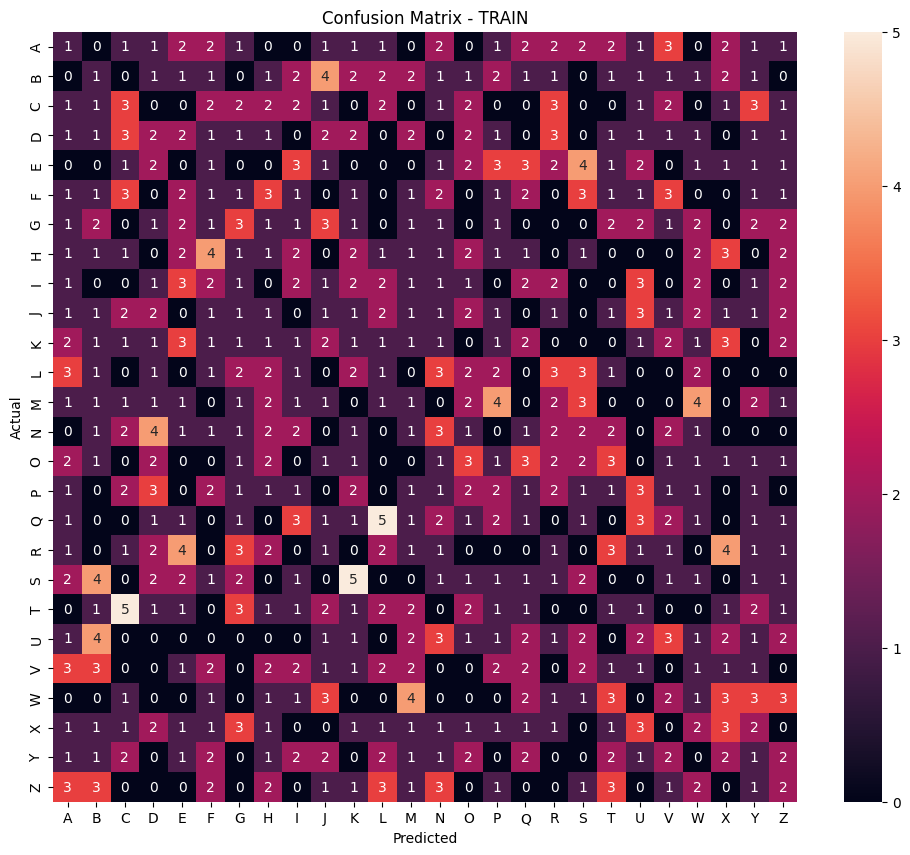

EVALUASI DATA VALIDATION
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 932ms/step

CONFUSION MATRIX



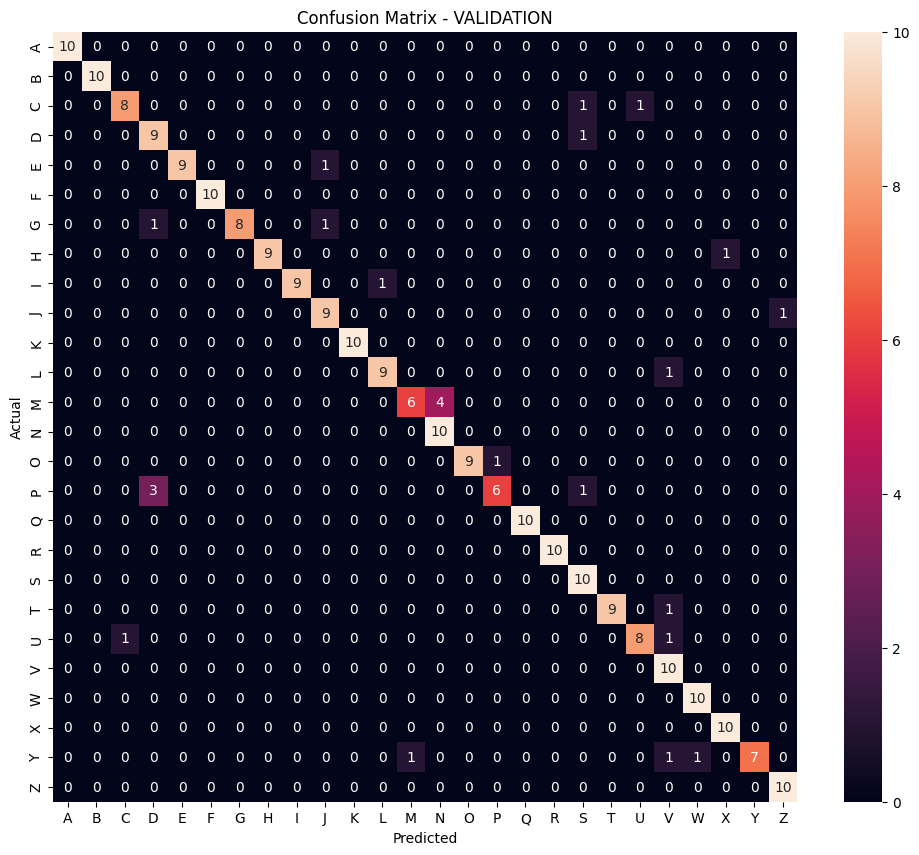

In [ ]:
evaluate_generator(model, train_generator, "TRAIN")
evaluate_generator(model, val_generator, "VALIDATION")

In [ ]:
# --- EVALUASI ---
MODEL_SAVE_PATH = '/content/drive/MyDrive/Skripsi_dataset/fix_bisindo_finetuned.keras'

print("="*60)
print("EVALUASI MODEL ResNet-50 Pre-trained")
print("="*60 + "\n")

print("Loading model terbaik...")
best_model = load_model(MODEL_SAVE_PATH)
print("✓ Model berhasil di-load\n")

print("Menyiapkan data generator untuk evaluasi...")
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False)

class_names = list(test_generator.class_indices.keys())
num_classes = len(class_names)
total_samples = test_generator.samples

print(f"Total test samples: {total_samples}")
print(f"Jumlah kelas: {num_classes}")
print(f"Kelas terdeteksi: {class_names}\n")

print("Sedang melakukan prediksi pada data test...")
test_generator.reset()

y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"✓ Prediksi selesai. Total prediksi: {len(y_pred)}\n")

print("Mengambil true labels dari generator...")
test_generator.reset()

y_true = test_generator.classes

min_length = min(len(y_true), len(y_pred))
y_true = y_true[:min_length]
y_pred = y_pred[:min_length]

print(f"✓ True labels berhasil diambil. Total: {len(y_true)}\n")

EVALUASI MODEL ResNet-50 Pre-trained

Loading model terbaik...
✓ Model berhasil di-load

Menyiapkan data generator untuk evaluasi...
Found 260 images belonging to 26 classes.
Total test samples: 260
Jumlah kelas: 26
Kelas terdeteksi: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Sedang melakukan prediksi pada data test...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 836ms/step
✓ Prediksi selesai. Total prediksi: 260

Mengambil true labels dari generator...
✓ True labels berhasil diambil. Total: 260



Membuat confusion matrix...


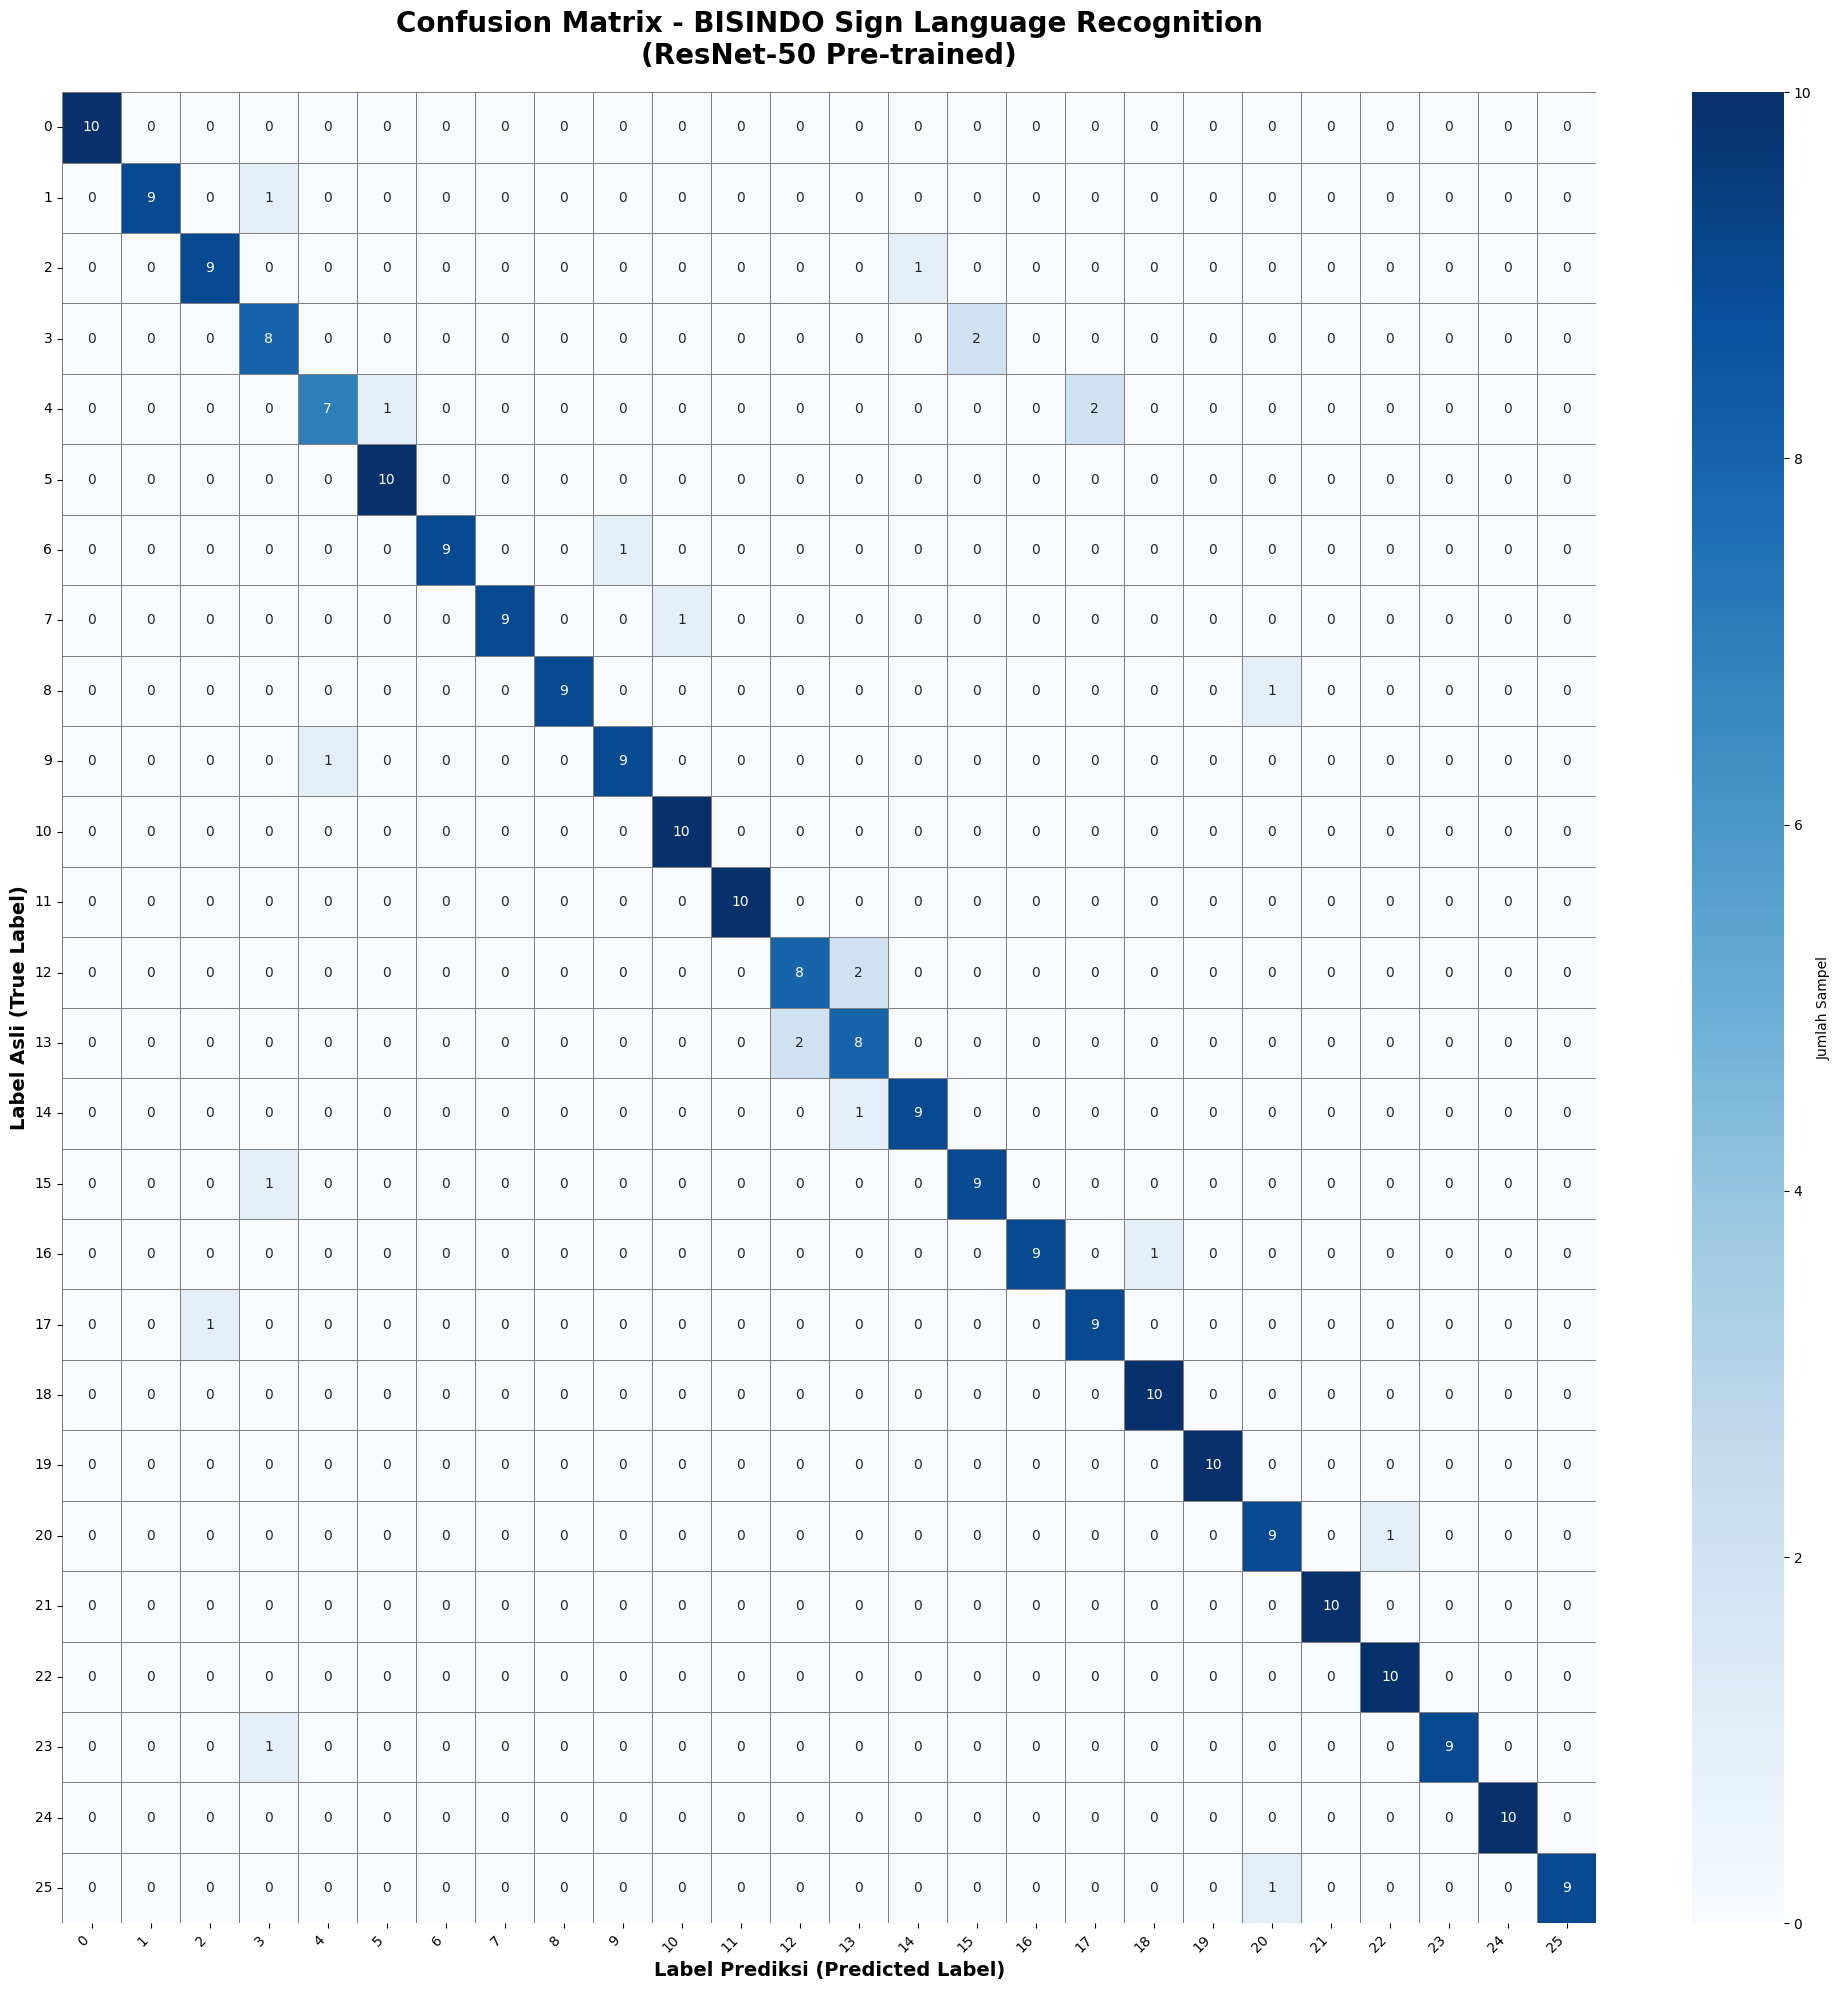

✓ Confusion matrix berhasil dibuat



In [ ]:
# --- CONFUSION MATRIX ---
print("Membuat confusion matrix...")

all_labels = np.arange(num_classes)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)

plt.figure(figsize=(20, 20))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Jumlah Sampel'},
    linewidths=0.5,
    linecolor='gray')

plt.title('Confusion Matrix - BISINDO Sign Language Recognition\n(ResNet-50 Pre-trained)',
          fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Label Asli (True Label)', fontsize=14, fontweight='bold')
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✓ Confusion matrix berhasil dibuat\n")

In [ ]:
# --- CLASSIFICATION REPORT ---
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60 + "\n")

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    labels=all_labels,
    target_names=class_names,
    digits=4)
print(report)

# --- METRIK TAMBAHAN ---
print("\n" + "="*60)
print("METRIK EVALUASI TAMBAHAN")
print("="*60 + "\n")

overall_accuracy = np.sum(y_true == y_pred) / len(y_true)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")

print("\nPer-Class Accuracy:")
print("-" * 50)
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    if np.sum(class_mask) > 0:
        class_accuracy = np.sum((y_true == i) & (y_pred == i)) / np.sum(class_mask)
        total_samples_class = np.sum(class_mask)
        correct_predictions = np.sum((y_true == i) & (y_pred == i))
        print(f"{class_name:15s}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%) - "
              f"Correct: {correct_predictions}/{total_samples_class}")

if num_classes >= 5:
    top5_pred = np.argsort(y_pred_probs, axis=1)[:, -5:]
    top5_accuracy = np.mean([y_true[i] in top5_pred[i] for i in range(len(y_true))])
    print(f"\nTop-5 Accuracy: {top5_accuracy:.4f} ({top5_accuracy*100:.2f}%)")

# --- ANALISIS KESALAHAN PREDIKSI ---
print("\n" + "="*60)
print("ANALISIS KESALAHAN PREDIKSI (Top 10)")
print("="*60 + "\n")

error_counts = {}
for i in range(num_classes):
    false_positive = np.sum((y_pred == i) & (y_true != i))
    false_negative = np.sum((y_true == i) & (y_pred != i))
    error_counts[class_names[i]] = {
        'false_positive': false_positive,
        'false_negative': false_negative,
        'total_error': false_positive + false_negative}

sorted_errors = sorted(error_counts.items(), key=lambda x: x[1]['total_error'], reverse=True)

print("Kelas dengan kesalahan prediksi terbanyak:")
print("-" * 70)
print(f"{'Kelas':<15} {'False Positive':<20} {'False Negative':<20} {'Total Error':<15}")
print("-" * 70)

for i, (class_name, errors) in enumerate(sorted_errors[:10]):
    print(f"{class_name:<15} {errors['false_positive']:<20} "
          f"{errors['false_negative']:<20} {errors['total_error']:<15}")

# --- CONFUSION PAIRS ---
print("\n" + "="*60)
print("TOP 10 CONFUSION PAIRS (Pasangan Kelas yang Sering Tertukar)")
print("="*60 + "\n")

confusion_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'true_class': class_names[i],
                'pred_class': class_names[j],
                'count': cm[i, j]})

confusion_pairs_sorted = sorted(confusion_pairs, key=lambda x: x['count'], reverse=True)

print(f"{'True Label':<15} {'→ Predicted As':<15} {'Count':<10}")
print("-" * 45)
for pair in confusion_pairs_sorted[:10]:
    print(f"{pair['true_class']:<15} → {pair['pred_class']:<15} {pair['count']:<10}")

print("\n" + "="*60)
print("EVALUASI SELESAI")
print("="*60)

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        10
           B     1.0000    0.9000    0.9474        10
           C     0.9000    0.9000    0.9000        10
           D     0.7273    0.8000    0.7619        10
           E     0.8750    0.7000    0.7778        10
           F     0.9091    1.0000    0.9524        10
           G     1.0000    0.9000    0.9474        10
           H     1.0000    0.9000    0.9474        10
           I     1.0000    0.9000    0.9474        10
           J     0.9000    0.9000    0.9000        10
           K     0.9091    1.0000    0.9524        10
           L     1.0000    1.0000    1.0000        10
           M     0.8000    0.8000    0.8000        10
           N     0.7273    0.8000    0.7619        10
           O     0.9000    0.9000    0.9000        10
           P     0.8182    0.9000    0.8571        10
           Q     1.0000    0.9000    0.9474        10
    

In [ ]:
# --- EVALUASI FINAL ---
print("\n" + "="*60)
print("EVALUASI FINAL")
print("="*60 + "\n")

best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

val_loss, val_accuracy = best_model.evaluate(test_generator)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")


EVALUASI FINAL

9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 477ms/step - accuracy: 0.9062 - loss: 0.2577

Validation Loss: 0.2481
Validation Accuracy: 0.9154 (91.54%)


In [ ]:
with open("/content/drive/MyDrive/Skripsi_dataset/fix_class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)